# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

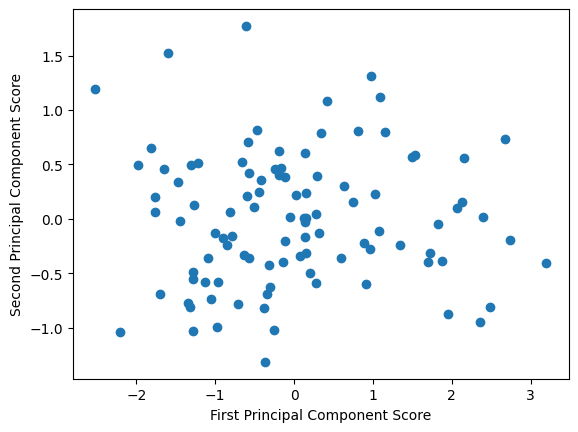

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
predict_conversion_df = pd.read_csv("predict-conversion-dataset.csv")


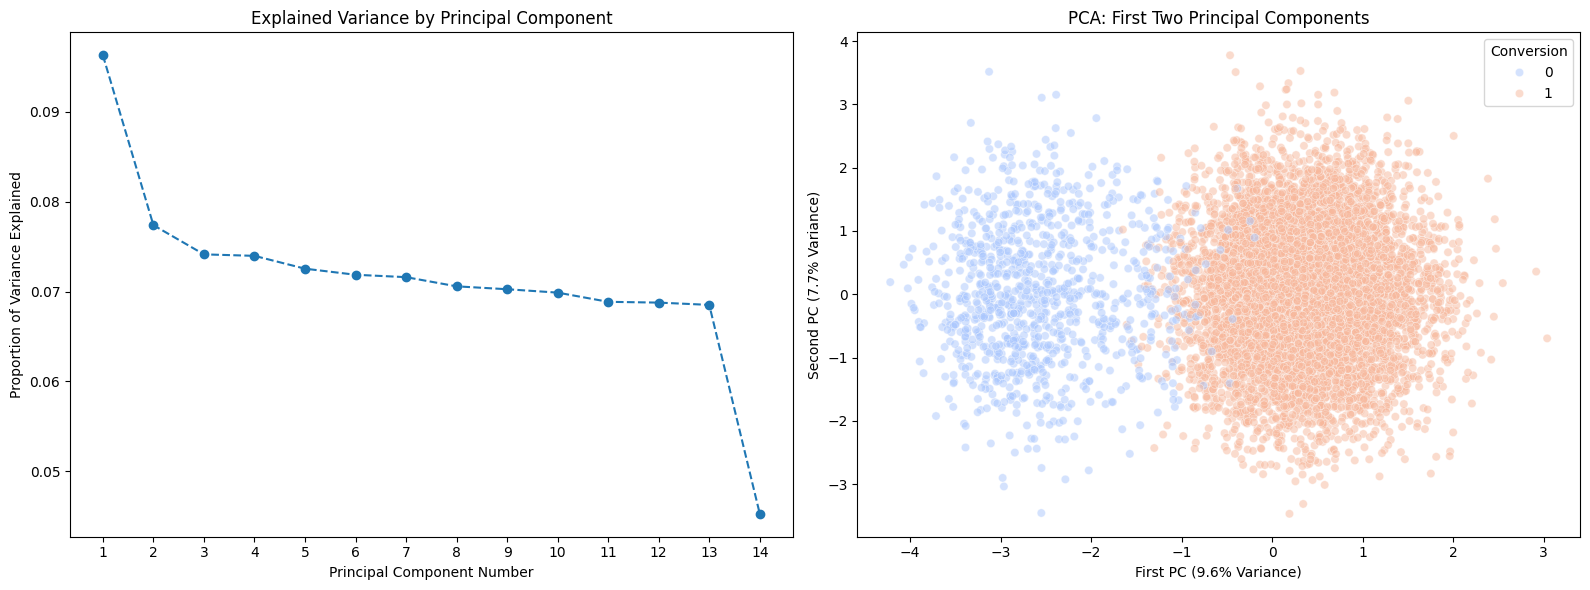

Top feature contributors to the First Principal Component:
Conversion           0.712699
EmailOpens           0.269637
EmailClicks          0.267703
AdSpend              0.253703
TimeOnSite           0.252356
PreviousPurchases    0.216949
PagesPerVisit        0.203051
ClickThroughRate     0.202166
ConversionRate       0.181888
LoyaltyPoints        0.175076
WebsiteVisits        0.141282
Income               0.056213
Age                  0.025369
SocialShares        -0.054543
dtype: float64


In [4]:
# PCA analysis predict_conversion_df 

# filter out categorical columns and the CustomerID
numeric_cols = predict_conversion_df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'], errors='ignore')

# Drop any missing values
numeric_cols = numeric_cols.dropna()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

# Fit PCA
pca = PCA()
pca.fit(scaled_data)

# Scores for first two principal components
pca_scores = pca.transform(scaled_data)

# Plot the explained variance and the first two components
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
axes[0].set_title('Explained Variance by Principal Component')
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Scatter plot of the first two principal components
scatter = sns.scatterplot(
    x=pca_scores[:, 0], y=pca_scores[:, 1], 
    hue=numeric_cols['Conversion'] if 'Conversion' in numeric_cols.columns else None,
    alpha=0.5, palette='coolwarm', ax=axes[1]
)
axes[1].set_title('PCA: First Two Principal Components')
axes[1].set_xlabel(f'First PC ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[1].set_ylabel(f'Second PC ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')

if 'Conversion' in numeric_cols.columns:
    axes[1].legend(title='Conversion', loc='best')

plt.tight_layout()
plt.show()

# Top contributors of the first Principal Component
print("Top feature contributors to the First Principal Component:")
pc1_components = pd.Series(pca.components_[0], index=numeric_cols.columns).sort_values(ascending=False)
print(pc1_components)

Linear Regression Performance predicting 'ConversionRate':
R-squared: 0.0015 (Explains 0.15% of the variance)
Mean Squared Error: 0.0029

Features most likely to be useful (highest coefficients):
          Feature   Coefficient
 ClickThroughRate -3.468925e-03
PreviousPurchases -4.325282e-04
    PagesPerVisit  3.936710e-04
      EmailClicks  1.832891e-04
       TimeOnSite  7.824601e-05
              Age  5.119390e-05
    WebsiteVisits -2.595239e-05
       EmailOpens  1.375614e-05
     SocialShares  7.737118e-06
          AdSpend -4.186464e-07


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_23300\3847020455.py:37

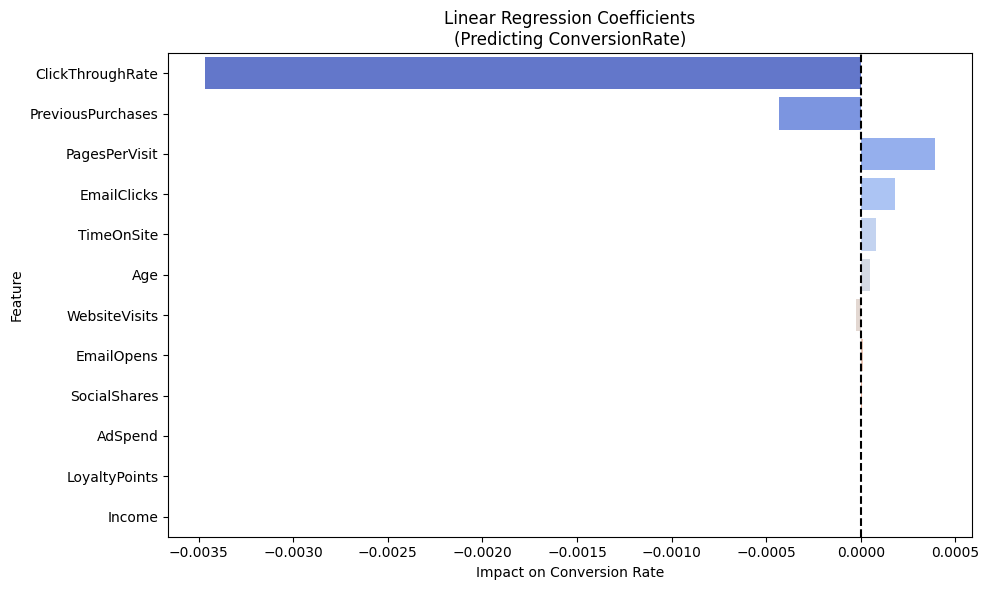

In [5]:
# Linear Regression analysis for predict_conversion_df

# Filter to numeric columns and drop the target 'ConversionRate', the binary 'Conversion', and 'CustomerID'
target_col = 'ConversionRate'
numeric_df = predict_conversion_df.select_dtypes(include=[np.number]).dropna()
X = numeric_df.drop(columns=[target_col, 'Conversion', 'CustomerID'], errors='ignore')
y = numeric_df[target_col]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Evaluate the model
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression Performance predicting '{target_col}':")
print(f"R-squared: {r2:.4f} (Explains {r2*100:.2f}% of the variance)")
print(f"Mean Squared Error: {mse:.4f}\n")

# Analyze Feature Importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("Features most likely to be useful (highest coefficients):")
print(coefficients[['Feature', 'Coefficient']].head(10).to_string(index=False))

# Visualize the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='coolwarm')
plt.title('Linear Regression Coefficients\n(Predicting ConversionRate)')
plt.xlabel('Impact on Conversion Rate')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

The PCA charts show that the first principle component is the target variable, which separates the data into two distinct groups. Looking at the following principle components, EmailOpens and EmailClicks are the next strongest positive correlations. This suggests that customers who convert are those that engage the most with marketing emais and ads. The linear regression model was not the best for the predict_conversion_df with an R-squared of 0.0015. The data generating the ConversionRate seems to rely on non-linear relationships or on randomness. According to the linear weights, ClickThroughRate, PagesPerVisit, and PreviousPurchases have the greatest pull on the regression line.  Perhaps using Random Forests or Gradient Boosting may be better suited. 

In [6]:
google_ads_df = pd.read_csv('google-ads-dataset.csv')

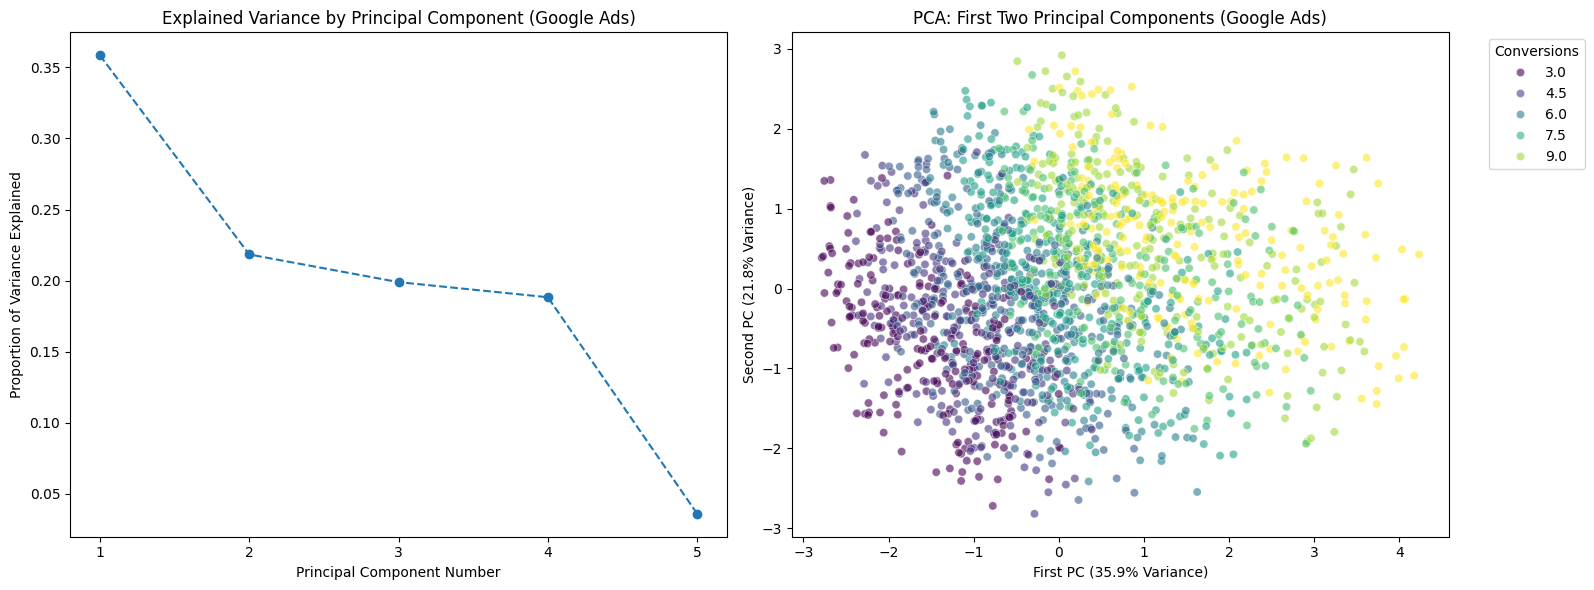

Top feature contributors to the First Principal Component (Google Ads):
Conversion Rate    0.712682
Conversions        0.563289
Impressions        0.017392
Leads             -0.042083
Clicks            -0.415591
dtype: float64


In [7]:
#
# Filter out categorical and ID columns
numeric_ads = google_ads_df.select_dtypes(include=[np.number]).dropna()

cols_to_drop = [col for col in numeric_ads.columns if 'id' in col.lower()]
numeric_ads = numeric_ads.drop(columns=cols_to_drop, errors='ignore')

# Standardize the data
scaler_ads = StandardScaler()
scaled_ads_data = scaler_ads.fit_transform(numeric_ads)

# Fit PCA
pca_ads = PCA()
pca_ads.fit(scaled_ads_data)
pca_ads_scores = pca_ads.transform(scaled_ads_data)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].plot(range(1, len(pca_ads.explained_variance_ratio_) + 1), pca_ads.explained_variance_ratio_, marker='o', linestyle='--')
axes[0].set_title('Explained Variance by Principal Component (Google Ads)')
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_xticks(range(1, len(pca_ads.explained_variance_ratio_) + 1))

# Define hue if there is a logical segment target (like 'Conversions' or 'Clicks')
hue_col = None
for col in ['Conversions', 'Conversion', 'Clicks', 'clicks']:
    if col in numeric_ads.columns:
        hue_col = numeric_ads[col]
        break

# PCA Scatter plot
sns.scatterplot(
    x=pca_ads_scores[:, 0], y=pca_ads_scores[:, 1], 
    hue=hue_col,
    alpha=0.6, palette='viridis' if hue_col is not None else None, ax=axes[1]
)
axes[1].set_title('PCA: First Two Principal Components (Google Ads)')
axes[1].set_xlabel(f'First PC ({pca_ads.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[1].set_ylabel(f'Second PC ({pca_ads.explained_variance_ratio_[1]*100:.1f}% Variance)')

if hue_col is not None:
    axes[1].legend(title=hue_col.name, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Top feature contributors of the first prinipcal component
print("Top feature contributors to the First Principal Component (Google Ads):")
pc1_ads_components = pd.Series(pca_ads.components_[0], index=numeric_ads.columns).sort_values(ascending=False)
print(pc1_ads_components.head(10))

Linear Regression Performance predicting 'Conversion Rate':
R-squared: 0.2893 (Explains 28.93% of the variance)
Mean Squared Error: 0.0003

Features (highest coefficients):
    Feature   Coefficient
     Clicks -2.597138e-04
      Leads  3.708626e-05
Impressions -3.891933e-08


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_23300\3434657238.py:52

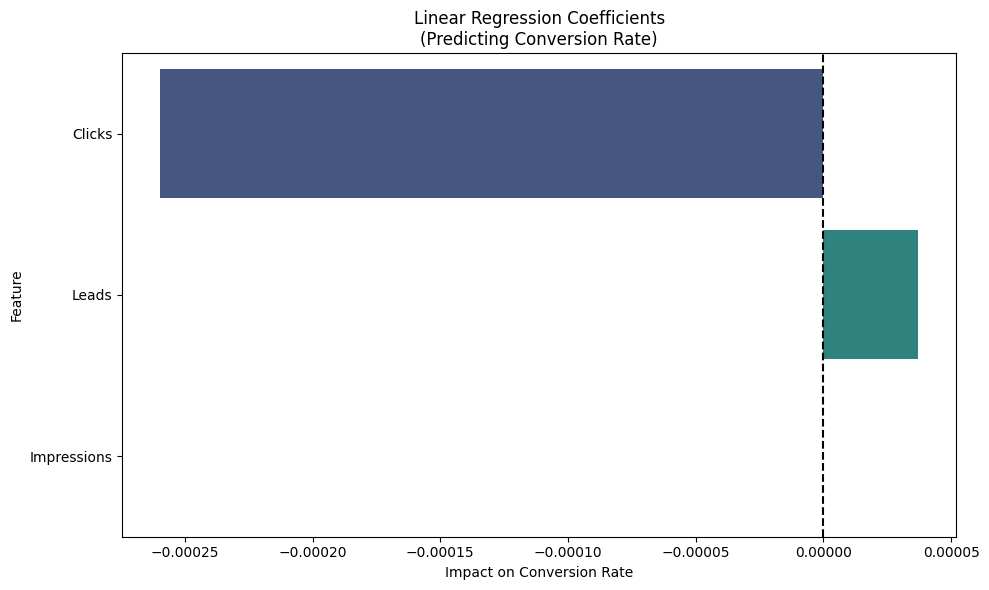

In [8]:
# Liinear Regression analysis google_ads_df

# identify the target column
target_col_ads = None
if 'Conversion Rate' in google_ads_df.columns:
    target_col_ads = 'Conversion Rate'
elif 'Conversions' in google_ads_df.columns:
    target_col_ads = 'Conversions'
else:
    # In case names are slightly different
    for col in google_ads_df.columns:
        if 'conversion' in col.lower():
            target_col_ads = col
            break

if target_col_ads:
    # Filter numeric columns and drop the target and ID columns
    numeric_ads_df = google_ads_df.select_dtypes(include=[np.number]).dropna()
    cols_to_drop = [col for col in numeric_ads_df.columns if 'id' in col.lower()]
    
    X_ads = numeric_ads_df.drop(columns=[target_col_ads, 'Conversions'] + cols_to_drop, errors='ignore')
    y_ads = numeric_ads_df[target_col_ads]
    
    # Split data into training and testing sets
    X_t_ads, X_test_ads, y_t_ads, y_test_ads = train_test_split(X_ads, y_ads, test_size=0.2, random_state=42)
    
    # Fit the Linear Regression model
    lr_model_ads = LinearRegression()
    lr_model_ads.fit(X_t_ads, y_t_ads)
    
    # Evaluate the model
    y_pred_ads = lr_model_ads.predict(X_test_ads)
    r2_ads = r2_score(y_test_ads, y_pred_ads)
    mse_ads = mean_squared_error(y_test_ads, y_pred_ads)
    
    print(f"Linear Regression Performance predicting '{target_col_ads}':")
    print(f"R-squared: {r2_ads:.4f} (Explains {r2_ads*100:.2f}% of the variance)")
    print(f"Mean Squared Error: {mse_ads:.4f}\n")
    
    # Analyze Feature Importance
    coefficients_ads = pd.DataFrame({
        'Feature': X_ads.columns,
        'Coefficient': lr_model_ads.coef_,
        'Abs_Coefficient': np.abs(lr_model_ads.coef_)
    }).sort_values(by='Abs_Coefficient', ascending=False)
    
    print("Features (highest coefficients):")
    print(coefficients_ads[['Feature', 'Coefficient']].to_string(index=False))
    
    # Visualize the coefficients
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients_ads, palette='viridis')
    plt.title(f'Linear Regression Coefficients\n(Predicting {target_col_ads})')
    plt.xlabel(f'Impact on {target_col_ads}')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a target column related to conversions.")

The PCA analysis showed how the target clusters neatly on the scatter plot, confirming that the first principal component successfully isolated the underlying mechanics. This indicates that it is a great feature for predictive machine learning. Additionally, there is a strong negative weight to "Clicks" while "Conversions" is highly positive, showing an inverse relationship. The linear regression analysis dmeonstrates that as the number of clicks increases, the predicted conversion rate decreases. This can occur due to an ad generating empty or low-intent clicks that do not lead to actual conversions, like clickbaiting. The "Leads" however have a positive correlation with a higher conversion rate, suggesting that when users commit to an action it is a strong indicator of traffic that eventually converts. It seems that focusing on attracting quality engagement is move beneficial than the quantity of engagement. 

In [9]:
marketing_and_product_df = pd.read_csv("marketing-and-product-dataset.csv")

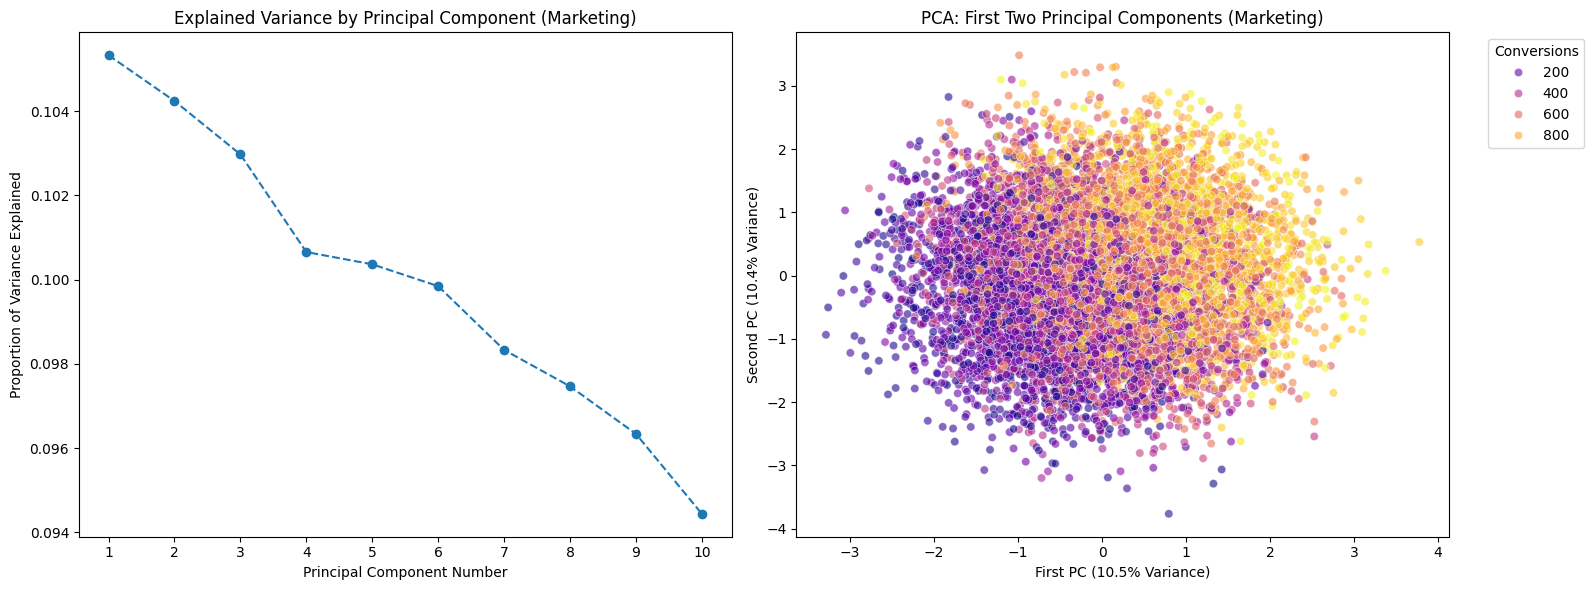

Top feature contributors to the First Principal Component (Marketing):
Conversions                          0.512514
Customer_Satisfaction_Post_Refund    0.162161
Revenue_Generated                    0.146971
Subscription_Length                  0.126083
Units_Sold                          -0.039840
Clicks                              -0.145505
Discount_Level                      -0.332605
Budget                              -0.371810
ROI                                 -0.440084
Bundle_Price                        -0.456326
dtype: float64


In [10]:
# PCA analysis for marketing_and_product_df

# Filter out categorical columns and drop identifier columns
numeric_mp = marketing_and_product_df.select_dtypes(include=[np.number]).dropna()
cols_to_drop_mp = [col for col in numeric_mp.columns if 'id' in col.lower()]
numeric_mp = numeric_mp.drop(columns=cols_to_drop_mp, errors='ignore')

# Standardize the data
scaler_mp = StandardScaler()
scaled_mp_data = scaler_mp.fit_transform(numeric_mp)

# Fit PCA
pca_mp = PCA()
pca_mp.fit(scaled_mp_data)

# Scores for first two principal components
pca_mp_scores = pca_mp.transform(scaled_mp_data)

# Plot explained variance and the first two components
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].plot(range(1, len(pca_mp.explained_variance_ratio_) + 1), pca_mp.explained_variance_ratio_, marker='o', linestyle='--')
axes[0].set_title('Explained Variance by Principal Component (Marketing)')
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_xticks(range(1, len(pca_mp.explained_variance_ratio_) + 1))

# Scatter plot of the first two principal components
hue_col_mp = None
for col in ['Revenue', 'Conversions', 'Sales']:
    if col in numeric_mp.columns:
        hue_col_mp = numeric_mp[col]
        break

sns.scatterplot(
    x=pca_mp_scores[:, 0], y=pca_mp_scores[:, 1], 
    hue=hue_col_mp,
    alpha=0.6, palette='plasma' if hue_col_mp is not None else None, ax=axes[1]
)
axes[1].set_title('PCA: First Two Principal Components (Marketing)')
axes[1].set_xlabel(f'First PC ({pca_mp.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[1].set_ylabel(f'Second PC ({pca_mp.explained_variance_ratio_[1]*100:.1f}% Variance)')

if hue_col_mp is not None:
    axes[1].legend(title=hue_col_mp.name, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Top contributors of the first Principal Component
print("Top feature contributors to the First Principal Component (Marketing):")
pc1_mp_components = pd.Series(pca_mp.components_[0], index=numeric_mp.columns).sort_values(ascending=False)
print(pc1_mp_components.head(10))

Linear Regression Performance predicting 'Conversions':
R-squared: -0.0002 (Explains -0.02% of the variance)
Mean Squared Error: 84678.4032

Features most likely to be useful (highest coefficients):
                          Feature  Coefficient
Customer_Satisfaction_Post_Refund     1.442623
                              ROI    -1.067968
                   Discount_Level    -0.329694
              Subscription_Length     0.140929
                       Units_Sold     0.068547
                     Bundle_Price    -0.038697
                           Clicks     0.002907
                           Budget    -0.000411
                Revenue_Generated    -0.000031


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_23300\139554357.py:48:

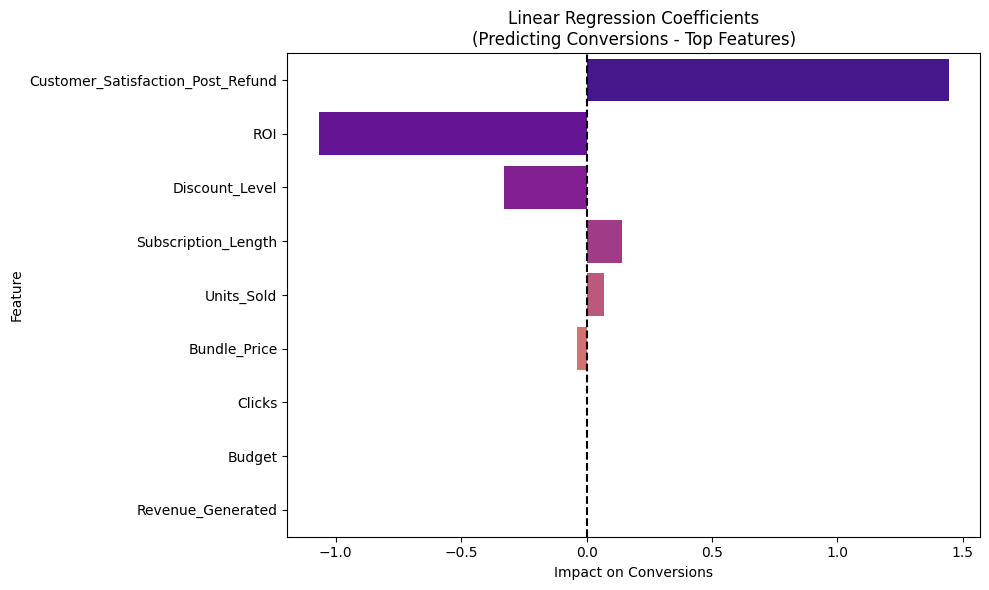

In [11]:
# Linear Regression analysis for marketing_and_product_df

# identify the target column
target_col_mp = None
for col in ['Conversions', 'Conversion', 'Revenue']:
    if col in marketing_and_product_df.columns:
        target_col_mp = col
        break

if target_col_mp:
    # Filter numeric columns and drop target, revenue, and ID columns
    numeric_mp_df = marketing_and_product_df.select_dtypes(include=[np.number]).dropna()
    cols_to_drop_mp = [col for col in numeric_mp_df.columns if 'id' in col.lower()]
    
    cols_to_drop_mp.extend([c for c in ['Revenue', 'Conversions'] if c in numeric_mp_df.columns and c != target_col_mp])
    
    X_mp = numeric_mp_df.drop(columns=[target_col_mp] + cols_to_drop_mp, errors='ignore')
    y_mp = numeric_mp_df[target_col_mp]
    
    # Split data into training and testing sets
    X_train_mp, X_test_mp, y_train_mp, y_test_mp = train_test_split(X_mp, y_mp, test_size=0.2, random_state=42)
    
    # Fit the Linear Regression model
    lr_model_mp = LinearRegression()
    lr_model_mp.fit(X_train_mp, y_train_mp)
    
    # Evaluate the model
    y_pred_mp = lr_model_mp.predict(X_test_mp)
    r2_mp = r2_score(y_test_mp, y_pred_mp)
    mse_mp = mean_squared_error(y_test_mp, y_pred_mp)
    
    print(f"Linear Regression Performance predicting '{target_col_mp}':")
    print(f"R-squared: {r2_mp:.4f} (Explains {r2_mp*100:.2f}% of the variance)")
    print(f"Mean Squared Error: {mse_mp:.4f}\n")
    
    # Analyze Feature Importance
    coefficients_mp = pd.DataFrame({
        'Feature': X_mp.columns,
        'Coefficient': lr_model_mp.coef_,
        'Abs_Coefficient': np.abs(lr_model_mp.coef_)
    }).sort_values(by='Abs_Coefficient', ascending=False)
    
    print("Features most likely to be useful (highest coefficients):")
    print(coefficients_mp[['Feature', 'Coefficient']].head(10).to_string(index=False))
    
    # Visualize the coefficients
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients_mp.head(15), palette='plasma')
    plt.title(f'Linear Regression Coefficients\n(Predicting {target_col_mp} - Top Features)')
    plt.xlabel(f'Impact on {target_col_mp}')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a suitable target column related to conversions or revenue.")

Based on the PCA charts, the data does not have a dominant underlying pattern nor any highly correlated features. The first principal component only explains roughly 10.5% of the variance, almost all the variables contribute equally, indicating that PCA is not a good tool for this specific dataset. Although there is a slight color gradient, there is a lack of clustering leading the plot to be overlapping. The linear regression analysis shows that "Customer_Satisfaction_Post_Refund" has the strongest positive impact, indicating that customer satisfaction is a strong predictor of increased conversions. The "ROI" has a strong inverse relationship, indicating that campaigns with massive conversion volumes might be operating at a lower ROI. The "Clicks", "Budget", and "revenue_Generated" have extremely low coefficients, which is in line with the idea of focusing on quality and satisfaction metrics rather than on quantitative ones. 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

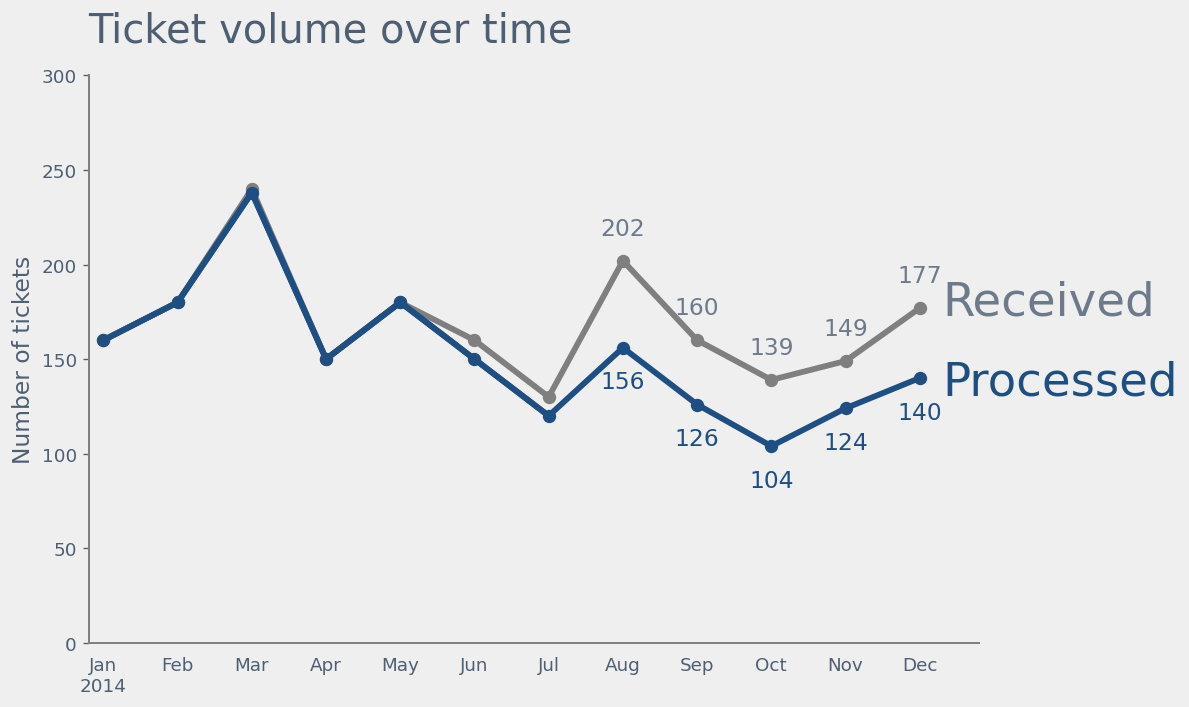

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Months and approximate values from the reference graphic
months = ["Jan\n2014", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = np.arange(len(months))

processed = np.array([160, 180, 238, 150, 180, 150, 120, 156, 126, 104, 124, 140])
received  = np.array([160, 180, 240, 150, 180, 160, 130, 202, 160, 139, 149, 177])

# Color palette and background close to the original look
bg = "#efefef"
blue = "#1f4f82"
gray = "#7f7f7f"

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# Main lines
ax.plot(x, received, color=gray, linewidth=3.5, marker="o", markersize=7, zorder=3)
ax.plot(x, processed, color=blue, linewidth=3.5, marker="o", markersize=7, zorder=4)

# Make first 7 months appear as one dark-blue line (as in the reference)
ax.plot(x[:7], processed[:7], color=blue, linewidth=3.5, zorder=5)

# Title and labels
ax.set_title("Ticket volume over time", loc="left", fontsize=24, color="#4f5f73", pad=20)
ax.set_ylabel("Number of tickets", fontsize=14, color="#4f5f73")
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11, color="#4f5f73")
ax.tick_params(axis="y", labelsize=11, colors="#4f5f73")
ax.tick_params(axis="x", length=0, pad=8)

# Axis range and ticks
ax.set_ylim(0, 300)
ax.set_yticks(np.arange(0, 301, 50))

ax.grid(False)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#808080")
    ax.spines[side].set_linewidth(1.2)

# Label key values from Aug-Dec
for i in [7, 8, 9, 10, 11]:
    ax.text(x[i], received[i] + 11, f"{received[i]}", color="#6d7a8c", fontsize=14, ha="center", va="bottom")
    ax.text(x[i], processed[i] - 12, f"{processed[i]}", color=blue, fontsize=14, ha="center", va="top")

# Series names on the right side
ax.text(x[-1] + 0.30, received[-1] + 3, "Received", color="#6d7a8c", fontsize=28, va="center")
ax.text(x[-1] + 0.30, processed[-1] - 2, "Processed", color=blue, fontsize=28, va="center")

# room for right end labels
ax.set_xlim(-0.2, len(months) - 0.2)

plt.tight_layout()
plt.show()